# 딥러닝 핵심 요소 비교 실험
## 손실 함수 / 활성화 함수 / 최적화 알고리즘이 학습에 미치는 영향 분석

| 실험 | 비교 대상                          | 데이터셋      |
|------|------------------------------------|---------------|
| A    | CrossEntropy vs MSE (with softmax) | Fashion-MNIST |
| B    | ReLU vs LeakyReLU vs Sigmoid       | make_moons    |
| C    | SGD vs SGD+Momentum vs Adam        | Fashion-MNIST |

## 보고서 표 항목과 코드 출력 대응
- 실험 A 표 : 최종 정확도(%) / 최솟값 Test Loss / 수렴 에폭(80%) / Loss 안정성
- 실험 B 표 : Dead L1(%) / Dead L2(%) / 최종 정확도(%) / 수렴 에폭(90%) / 수렴 속도 / 안정성
- 실험 C 표 : 최종 정확도(%) / 최솟값 Loss / 수렴 에폭(80%) / 수렴 속도 / 안정성


## 0. 환경 설정 및 공통 유틸리티


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# 시드 고정: torch / numpy 모두 고정해야 재현성 보장
# ------------------------------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 장치 설정
# GPU 사용 가능 시 CUDA, 아닐 시 CPU 사용
# 모든 모델·텐서는 .to(device) 로 동일 장치로 이동해야 함
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

# ------------------------------------------------------------------------------
# 공통 하이퍼파라미터
#
# [강의 자료 에폭 가이드]
# Fashion-MNIST : 20~50 에폭 권장 → 30 에폭 사용
# make_moons    : 200~500 에폭 권장 → 300 에폭 사용
#
# BATCH_SIZE=64 : Mini-Batch Gradient Descent
# BGD(전체): 안정적, 계산량 많음 / SGD(1개): 빠르나 진동
# Mini-Batch: 두 방식의 장점을 균형 있게 취함
# ------------------------------------------------------------------------------
BATCH_SIZE   = 64
FMNIST_EPOCH = 30
MOONS_EPOCH  = 300

# 플롯 스타일
plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})


# ==============================================================================


사용 장치: cuda


## 1. 데이터셋 로드 — Fashion-MNIST

- 28×28 흑백 이미지, 10개 클래스
- 훈련 60,000 / 테스트 10,000
- Normalize: [0,1] → [-1,1] (평균 0.5, 표준편차 0.5)
  입력을 0 중심으로 맞춰 gradient 업데이트 방향 편향(zig-zag) 방지


In [3]:
transform_fmnist = transforms.Compose([
    transforms.ToTensor(),                   # PIL [0,255] → Tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))     # [0,1] → [-1,1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True,  download=True, transform=transform_fmnist
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform_fmnist
)

# shuffle=True : 매 에폭 순서를 섞어 순서 의존 과적합 방지
# num_workers=2: 데이터 로딩 병렬 처리 → GPU 대기 시간 단축
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

INPUT_SIZE  = 28 * 28   # 784: MLP 입력을 위해 1D Flatten
NUM_CLASSES = 10

print(f"Fashion-MNIST | 훈련: {len(train_dataset):,}  테스트: {len(test_dataset):,}")


# ==============================================================================


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.86MB/s]

Fashion-MNIST | 훈련: 60,000  테스트: 10,000


## 2. 공통 MLP 모델

Linear(input, 256) → 활성화 → Linear(256, 128) → 활성화 → Linear(128, 출력)

[출력층 설계]
출력층에는 활성화 함수 없음 → logit(원시 점수) 출력
CrossEntropyLoss가 내부적으로 LogSoftmax를 포함하므로 중복 적용 금지
      
      "결론: 은닉층→ReLU, 출력층→Softmax(다중 클래스)"
       출력층에 ReLU를 쓰면 출력이 [0,∞) → 확률 해석 불가


In [4]:
class MLP(nn.Module):
    """
    Fashion-MNIST용 3층 MLP (784 → 256 → 128 → 10)

    activation : 실험마다 교체할 활성화 함수 인스턴스
                 nn.ReLU() / nn.LeakyReLU(0.01) / nn.Sigmoid()
    """
    def __init__(self, input_size, num_classes, activation):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 256)   # 입력 → 은닉층 1
        self.fc2 = nn.Linear(256, 128)           # 은닉층 1 → 은닉층 2
        self.fc3 = nn.Linear(128, num_classes)   # 은닉층 2 → 출력 (logit)
        self.activation = activation

    def forward(self, x):
        x = x.view(x.size(0), -1)          # Flatten: (B,1,28,28)→(B,784)
        x = self.activation(self.fc1(x))   # 은닉층 1: 선형 변환 + 활성화
        x = self.activation(self.fc2(x))   # 은닉층 2: 선형 변환 + 활성화
        x = self.fc3(x)                    # 출력층: 활성화 없음 (logit)
        return x


def init_weights(model, std=None):
    """
    가중치 초기화

    std=None  → Kaiming Uniform 유지 (ReLU 계열 최적화, 분산=2/fan_in)
    std=0.01  → N(0, 0.01²) → Dead ReLU 유도용 (실험 B)
                 pre-activation이 0 근방 집중 → 음수 多 → gradient=0 → Dead
    bias는 항상 0으로 초기화
    """
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if std is not None:
                nn.init.normal_(m.weight, mean=0.0, std=std)
            nn.init.zeros_(m.bias)
    return model


def build_model(activation, init_std=None):
    """모델 생성 + 초기화 + 장치 이동 한 번에 처리"""
    model = MLP(INPUT_SIZE, NUM_CLASSES, activation)
    return init_weights(model, std=init_std).to(device)


# ==============================================================================


## 3. 공통 학습 / 평가 루프

- for epoch in range(...) 형태로 직접 작성
- loss_fn = ... 명시적 설정
- model.eval() + torch.no_grad() 활용

[학습 1 에폭 흐름]
1. model.train()
2. optimizer.zero_grad()  ← 이전 배치 gradient 누적 초기화
3. outputs = model(inputs) ← Forward (logit 계산)
4. loss = loss_fn(...)     ← 손실 계산
5. loss.backward()         ← Backpropagation (autograd 자동 미분)
6. optimizer.step()        ← 파라미터 업데이트


In [5]:
def train_one_epoch(model, loader, loss_fn, optimizer, use_softmax=False):
    """
    한 에폭 학습

    use_softmax=True  → MSE 실험: logit에 softmax 적용 후 one-hot 타깃과 비교
                         softmax 없이 MSE 쓰면 logit 스케일 불일치 → 불안정
    use_softmax=False → CrossEntropy: logit 그대로 전달 (내부에서 처리)
                         CE gradient: dL/dw = (ŷ-y)·x  ← activation 미분 소거

    Returns: (avg_loss, accuracy)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)                # logit (B, num_classes)

        if use_softmax:
            # ── MSE 실험 ──────────────────────────────────────────────────────
            # softmax: ô_k = exp(z_k) / Σ exp(z_i) → [0,1] 확률
            # MSE gradient: dL/dw = (ŷ-y)·ŷ(1-ŷ)·x
            #        ŷ(1-ŷ) ≤ 0.25, 포화 시 ≈ 0 → gradient 소멸
            outputs_prob = torch.softmax(outputs, dim=1)
            # one-hot: 정수 레이블 → 벡터 (MSELoss는 같은 shape 필요)
            targets_onehot = torch.zeros_like(outputs_prob)
            targets_onehot.scatter_(1, labels.unsqueeze(1), 1.0)
            loss = loss_fn(outputs_prob, targets_onehot)
        else:
            # ── CrossEntropy ──────────────────────────────────────────────────
            # nn.CrossEntropyLoss = LogSoftmax + NLLLoss
            # CE gradient: dL/dw = (ŷ-y)·x  (activation 미분 소거)
            # log-sum-exp trick으로 overflow 방지 (내부 자동 처리)
            loss = loss_fn(outputs, labels)

        loss.backward()    # 연쇄법칙으로 모든 파라미터 gradient 계산
        optimizer.step()   # θ ← θ - η·∇L(θ) (optimizer별 업데이트 방식 적용)

        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, use_softmax=False):
    """
    테스트셋 평가

    model.eval()      : Dropout OFF, BN 추론 모드
    @torch.no_grad()  : gradient 그래프 생성 안 함 → 메모리·속도 절약

    Returns: (avg_loss, accuracy)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        if use_softmax:
            outputs_prob = torch.softmax(outputs, dim=1)
            targets_onehot = torch.zeros_like(outputs_prob)
            targets_onehot.scatter_(1, labels.unsqueeze(1), 1.0)
            loss = loss_fn(outputs_prob, targets_onehot)
        else:
            loss = loss_fn(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    return total_loss / total, correct / total


def run_experiment(model, loss_fn, optimizer, epochs,
                   use_softmax=False, scheduler=None, verbose_interval=5):
    """
    전체 학습 루프 실행 + 에폭별 기록 반환

    scheduler : ExponentialLR 등 스케줄러. 매 에폭 종료 후 step() 호출.
                lr_t = lr_0 * gamma^t → 초반 빠른 탐색 + 후반 안정화

    Returns: history dict { train_loss, train_acc, test_loss, test_acc }
    """
    history = {"train_loss": [], "train_acc": [],
               "test_loss" : [], "test_acc" : []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, loss_fn, optimizer, use_softmax)
        te_loss, te_acc = evaluate(
            model, test_loader, loss_fn, use_softmax)

        history["train_loss"].append(tr_loss)
        history["train_acc" ].append(tr_acc)
        history["test_loss" ].append(te_loss)
        history["test_acc"  ].append(te_acc)

        if scheduler is not None:
            scheduler.step()   # ExponentialLR: lr *= gamma

        if epoch % verbose_interval == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  | "
                  f"Test Loss: {te_loss:.4f}  Acc: {te_acc*100:.2f}%")

    return history


# ------------------------------------------------------------------------------
# 보고서 표 계산용 헬퍼 함수
# 아래 함수들이 보고서의 모든 수치 열을 생성한다.
# ------------------------------------------------------------------------------

def convergence_epoch(acc_list, threshold):
    """
    정확도 리스트에서 threshold를 처음 초과하는 에폭 번호 반환 (수렴 속도 지표).
    threshold 미도달 시 -1 반환.
    보고서 표: '수렴 에폭(80%)' 또는 '수렴 에폭(90%)'
    """
    for i, a in enumerate(acc_list):
        if a >= threshold:
            return i + 1
    return -1


def loss_stability(loss_list, window=5):
    """
    변동계수(CV = std/mean)로 안정성 판단.
    절대 스케일이 다른 손실 함수 간 비교에 적합.

    CV < 0.02  → 안정적
    CV < 0.08  → 보통
    CV >= 0.08 → 불안정 (진동)
    """
    tail = loss_list[-window:]
    std  = np.std(tail)
    mean = np.mean(tail)
    cv   = std / mean if mean > 0 else 0
    if cv < 0.02:
        return f"안정적 (CV={cv:.4f})"
    elif cv < 0.08:
        return f"보통 (CV={cv:.4f})"
    else:
        return f"불안정·진동 (CV={cv:.4f})"


def convergence_speed_label(conv_epoch, total_epochs):
    """
    수렴 에폭 기준으로 수렴 속도 레이블 반환.
    보고서 표: '수렴 속도'

    전체 에폭의 25% 이내 → 빠름
    전체 에폭의 50% 이내 → 중간
    그 이상 또는 미도달  → 느림
    """
    if conv_epoch == -1:
        return "느림 (미도달)"
    ratio = conv_epoch / total_epochs
    if ratio <= 0.25:
        return f"빠름 ({conv_epoch}에폭)"
    elif ratio <= 0.50:
        return f"중간 ({conv_epoch}에폭)"
    else:
        return f"느림 ({conv_epoch}에폭)"


def print_table_A(results):
    """
    보고서 실험 A 표 출력
    열: 실험항목 / 최종 정확도(%) / 최솟값 Test Loss / 수렴 에폭(80%) / Loss 안정성
    """
    print("\n" + "=" * 72)
    print("【실험 A 정량 비교표 ")
    print("=" * 72)
    print(f"{'실험 항목':<20} {'최종 정확도(%)':>14} {'최솟값 Loss':>12} "
          f"{'수렴 에폭(80%)':>14} {'Loss 안정성'}")
    print("-" * 72)
    for name, hist in results.items():
        acc   = hist["test_acc"][-1]  * 100
        mloss = min(hist["test_loss"])
        conv  = convergence_epoch(hist["test_acc"], 0.80)
        stab  = loss_stability(hist["test_loss"])
        print(f"  {name:<18} {acc:>14.2f} {mloss:>12.4f} {conv:>14} {stab}")
    print("=" * 72)


def print_table_B(results_b):
    """
    보고서 실험 B 표 출력
    열: 활성화함수 / Dead L1(%) / Dead L2(%) / 최종 정확도(%) /
        수렴 에폭(90%) / 수렴 속도 / 안정성
    """
    print("\n" + "=" * 90)
    print("【실험 B 정량 비교표】")
    print("=" * 90)
    print(f"{'활성화 함수':<14} {'Dead L1(%)':>10} {'Dead L2(%)':>10} "
          f"{'최종 정확도(%)':>14} {'수렴 에폭(90%)':>14} {'수렴 속도':<18} {'안정성'}")
    print("-" * 90)
    for name, (hist, dead_res) in results_b.items():
        d1    = dead_res["layer1"][1] * 100
        d2    = dead_res["layer2"][1] * 100
        acc   = hist["test_acc"][-1]  * 100
        conv  = convergence_epoch(hist["test_acc"], 0.90)
        speed = convergence_speed_label(conv, MOONS_EPOCH)
        stab  = loss_stability(hist["test_loss"])
        print(f"  {name:<12} {d1:>10.2f} {d2:>10.2f} {acc:>14.2f} "
              f"{conv:>14} {speed:<18} {stab}")
    print("=" * 90)


def print_table_C(results_c):
    """
    보고서 실험 C 표 출력
    열: Optimizer / lr / 최종 정확도(%) / 최솟값 Loss / 수렴 에폭(80%) / 수렴 속도 / 안정성
    """
    print("\n" + "=" * 95)
    print("【실험 C 정량 비교표】 ")
    print("=" * 95)
    print(f"{'Optimizer':<16} {'lr':>6} {'최종 정확도(%)':>14} {'최솟값 Loss':>12} "
          f"{'수렴 에폭(80%)':>14} {'수렴 속도':<20} {'안정성'}")
    print("-" * 95)
    for opt_name in ["SGD", "SGD+Momentum", "Adam"]:
        for lr in [0.1, 0.01, 0.001]:
            hist  = results_c[opt_name][lr]
            acc   = hist["test_acc"][-1]  * 100
            mloss = min(hist["test_loss"])
            conv  = convergence_epoch(hist["test_acc"], 0.80)
            speed = convergence_speed_label(conv, FMNIST_EPOCH)
            stab  = loss_stability(hist["test_loss"])
            print(f"  {opt_name:<14} {str(lr):>6} {acc:>14.2f} {mloss:>12.4f} "
                  f"{conv:>14} {speed:<20} {stab}")
        print()
    print("=" * 95)


# ==============================================================================


## 실험 A : 손실 함수 비교 — CrossEntropy vs MSE (with Softmax)


MSE gradient    : dL/dw = (ŷ-y)·ŷ(1-ŷ)·x   ← softmax 미분 항 남아있음
                  ŷ(1-ŷ) ≤ 0.25, 포화 시 → 0 → gradient 소멸
CE gradient     : dL/dw = (ŷ-y)·x            ← activation 미분 소거됨
                   "activation derivative가 gradient 식에서 자연스럽게
                          소거됨 → gradient 유지 → 깊은 네트워크에서도 학습 가능"

[실험 조건]

동일: MLP(784→256→128→10, ReLU), Adam(lr=0.001), 30 에폭
변경: loss_fn 만 교체


In [6]:
print("\n" + "=" * 60)
print("실험 A : CrossEntropy Loss vs MSE Loss (with Softmax)")
print("=" * 60)

# ── A-1 : CrossEntropy Loss ────────────────────────────────────────────────────
# nn.CrossEntropyLoss() 내부: LogSoftmax + NLLLoss
# log-sum-exp trick으로 수치 안정성 보장 (overflow 방지)
# max(z)를 빼서 exp 연산 안정화
print("\n[A-1] CrossEntropy Loss")
model_ce = build_model(nn.ReLU())
loss_ce  = nn.CrossEntropyLoss()
optim_ce = optim.Adam(model_ce.parameters(), lr=0.001)
# Adam: 0.001~0.01 → 0.001 사용
hist_ce  = run_experiment(model_ce, loss_ce, optim_ce, FMNIST_EPOCH)

# ── A-2 : MSE Loss + Softmax ──────────────────────────────────────────────────
# 분류에 MSE 적용 시 문제 확인 실험
# softmax 없이 MSE 쓰면 logit(-∞,+∞)와 타깃{0,1} 스케일 불일치 → 불안정
# softmax 명시 적용 후 one-hot 타깃과 비교해야 의미 있는 실험
print("\n[A-2] MSE Loss (with explicit Softmax)")
model_mse = build_model(nn.ReLU())
loss_mse  = nn.MSELoss()
optim_mse = optim.Adam(model_mse.parameters(), lr=0.001)
hist_mse  = run_experiment(model_mse, loss_mse, optim_mse,
                           FMNIST_EPOCH, use_softmax=True)

# ── 실험 A 보고서 표 출력 ──────────────────────────────────────────────────────
results_A = {
    "CrossEntropy"   : hist_ce,
    "MSE+Softmax"    : hist_mse,
}
print_table_A(results_A)


# ==============================================================================



실험 A : CrossEntropy Loss vs MSE Loss (with Softmax)

[A-1] CrossEntropy Loss
  Epoch   1/30 | Train Loss: 0.4966  Acc: 81.97%  | Test Loss: 0.4522  Acc: 83.70%
  Epoch   5/30 | Train Loss: 0.2848  Acc: 89.34%  | Test Loss: 0.3525  Acc: 87.29%
  Epoch  10/30 | Train Loss: 0.2215  Acc: 91.58%  | Test Loss: 0.3389  Acc: 88.63%
  Epoch  15/30 | Train Loss: 0.1793  Acc: 93.23%  | Test Loss: 0.3429  Acc: 88.89%
  Epoch  20/30 | Train Loss: 0.1419  Acc: 94.63%  | Test Loss: 0.3800  Acc: 88.97%
  Epoch  25/30 | Train Loss: 0.1188  Acc: 95.51%  | Test Loss: 0.4307  Acc: 89.08%
  Epoch  30/30 | Train Loss: 0.1025  Acc: 96.06%  | Test Loss: 0.4740  Acc: 89.15%

[A-2] MSE Loss (with explicit Softmax)
  Epoch   1/30 | Train Loss: 0.0258  Acc: 81.77%  | Test Loss: 0.0214  Acc: 85.18%
  Epoch   5/30 | Train Loss: 0.0162  Acc: 88.84%  | Test Loss: 0.0193  Acc: 86.53%
  Epoch  10/30 | Train Loss: 0.0134  Acc: 90.83%  | Test Loss: 0.0175  Acc: 88.06%
  Epoch  15/30 | Train Loss: 0.0112  Acc: 92.62%  | 

## 실험 A 시각화


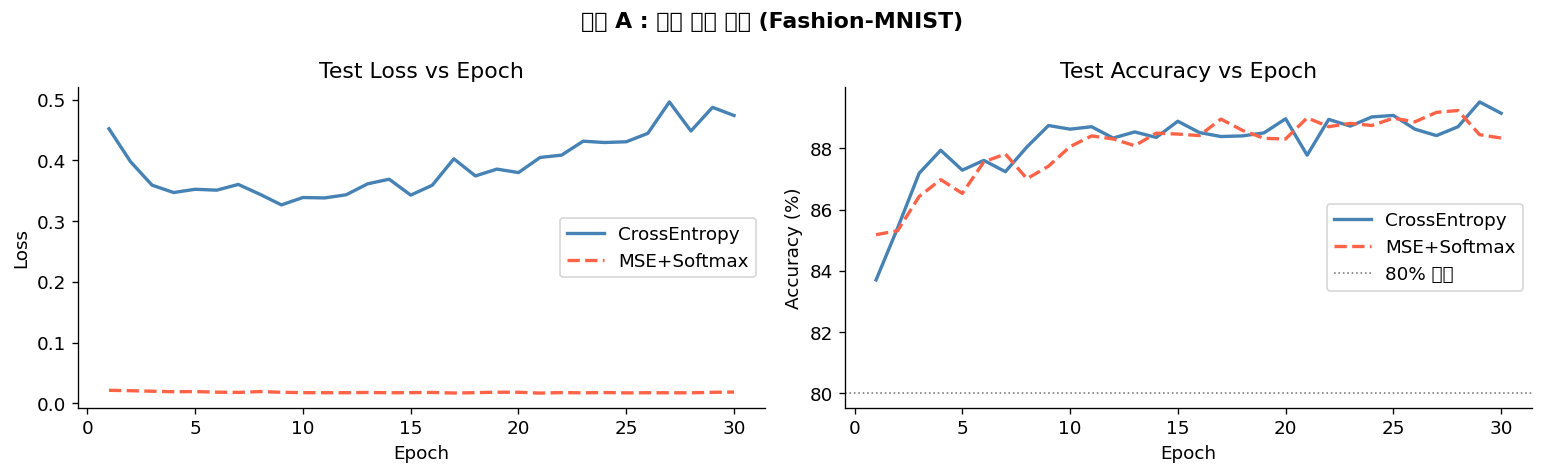

저장: exp_A_loss_acc.png


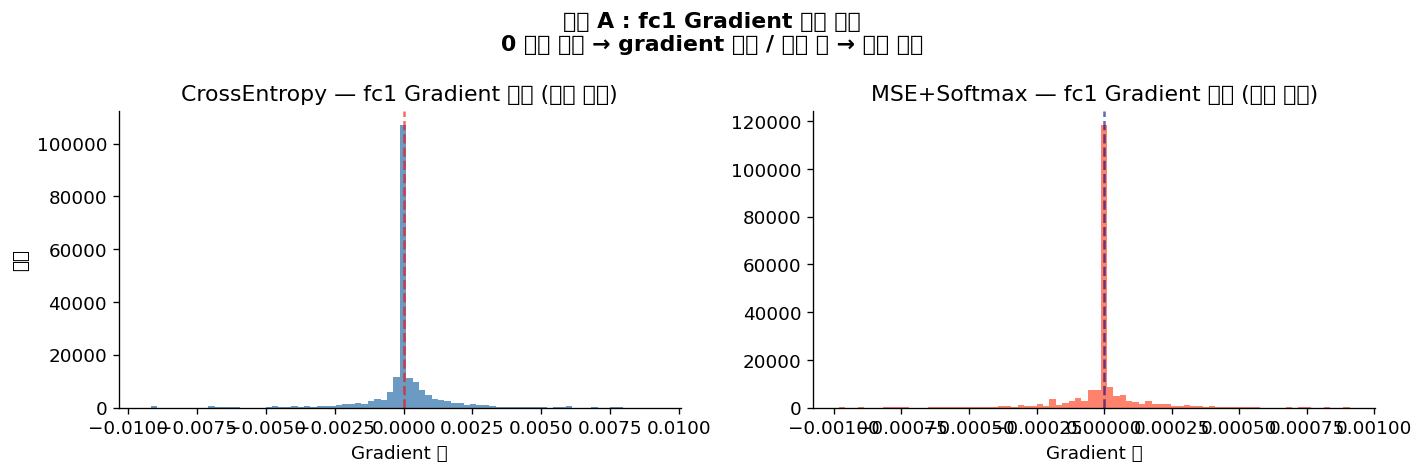

저장: exp_A_gradient.png


In [7]:
ep_a = range(1, FMNIST_EPOCH + 1)

# ── 그래프 1: Loss / Accuracy 곡선 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ep_a, hist_ce["test_loss"],
             label="CrossEntropy", linewidth=2, color="steelblue")
axes[0].plot(ep_a, hist_mse["test_loss"],
             label="MSE+Softmax",  linewidth=2, color="tomato", linestyle="--")
axes[0].set_title("Test Loss vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
# CE는 단조 감소, MSE는 정체/진동 구간을 Loss 안정성 열과 대조

axes[1].plot(ep_a, [a*100 for a in hist_ce["test_acc"]],
             label="CrossEntropy", linewidth=2, color="steelblue")
axes[1].plot(ep_a, [a*100 for a in hist_mse["test_acc"]],
             label="MSE+Softmax",  linewidth=2, color="tomato", linestyle="--")
axes[1].set_title("Test Accuracy vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend()
# 수렴 에폭(80%) 기준선 표시
axes[1].axhline(80, color="gray", linestyle=":", linewidth=1, label="80% 기준")
axes[1].legend()

plt.suptitle("실험 A : 손실 함수 비교 (Fashion-MNIST)", fontweight="bold")
plt.tight_layout()
plt.savefig("exp_A_loss_acc.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_A_loss_acc.png")

# ── 그래프 2: fc1 Gradient 분포 ───────────────────────────────────────────────
# fc1(입력층 쪽)에서 gradient가 0에 수렴하면
# 앞쪽 레이어 학습 불가 → Loss 정체
def get_grad_fc1(model, loader, loss_fn, use_softmax=False):
    """한 배치 backward 후 fc1 gradient flatten 배열 반환"""
    model.train()
    inputs, labels = next(iter(loader))
    inputs, labels = inputs.to(device), labels.to(device)
    model.zero_grad()
    outputs = model(inputs)
    if use_softmax:
        p = torch.softmax(outputs, dim=1)
        t = torch.zeros_like(p)
        t.scatter_(1, labels.unsqueeze(1), 1.0)
        loss_fn(p, t).backward()
    else:
        loss_fn(outputs, labels).backward()
    grads = model.fc1.weight.grad.detach().cpu().numpy().flatten()
    model.zero_grad()
    return grads

grads_ce  = get_grad_fc1(model_ce,  train_loader, loss_ce)
grads_mse = get_grad_fc1(model_mse, train_loader, loss_mse, use_softmax=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(grads_ce,  bins=80, color="steelblue", alpha=0.8)
axes[0].set_title("CrossEntropy — fc1 Gradient 분포 (학습 후반)")
axes[0].set_xlabel("Gradient 값"); axes[0].set_ylabel("빈도")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.6)

axes[1].hist(grads_mse, bins=80, color="tomato", alpha=0.8)
axes[1].set_title("MSE+Softmax — fc1 Gradient 분포 (학습 후반)")
axes[1].set_xlabel("Gradient 값")
axes[1].axvline(0, color="navy", linestyle="--", alpha=0.6)

plt.suptitle("실험 A : fc1 Gradient 분포 비교\n"
             "0 근방 집중 → gradient 소멸 / 분산 큼 → 정상 흐름",
             fontweight="bold")
plt.tight_layout()
plt.savefig("exp_A_gradient.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_A_gradient.png")


# ==============================================================================


## 실험 B : 활성화 함수 비교 — ReLU vs LeakyReLU vs Sigmoid


ReLU     : f(x)=max(0,x), f'(x)=1(x>0)/0(x≤0)
           장점: gradient=1 → Vanishing 해결, 계산 효율↑
           단점: Dying ReLU — x≤0 gradient=0 → 뉴런 영구 비활성
LeakyReLU: f(x)=x(x>0)/αx(x≤0), α=0.01
           음수 구간 기울기 α 유지 → Dead 뉴런 재활성 가능
Sigmoid  : σ(x)=1/(1+e^{-x}), σ'(x)=σ(1-σ) ≤ 0.25
            x→±∞ 시 σ'→0 → gradient 지수 감소 (0.25^L 이하)
           zero-centered 아님 → zig-zag 업데이트

[실험 조건]

동일: MLP(2→256→128→2), CrossEntropy, Adam(lr=0.001), 300 에폭
초기화: std=0.01 → Dead ReLU 유도 ["weight 초기값을 작게 설정"]
변경: activation 만 교체


In [8]:
print("\n" + "=" * 60)
print("실험 B : 활성화 함수 비교 (make_moons)")
print("=" * 60)

# ── make_moons 데이터 준비 ─────────────────────────────────────────────────────
# noise=0.2: 가우시안 노이즈 → 비선형 경계 불명확 → 활성화 함수 차이 부각
X_raw, y_raw = make_moons(n_samples=1000, noise=0.2, random_state=SEED)

# StandardScaler: 평균=0, 표준편차=1 → feature 스케일 균일화 → gradient 균형
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=SEED)

X_tr = torch.FloatTensor(X_train_b).to(device)
X_te = torch.FloatTensor(X_test_b ).to(device)
y_tr = torch.LongTensor(y_train_b ).to(device)
y_te = torch.LongTensor(y_test_b  ).to(device)

train_ds_b = TensorDataset(X_tr, y_tr)
train_ld_b = DataLoader(train_ds_b, batch_size=32, shuffle=True)

INPUT_B = 2   # 2차원 입력 (x₁, x₂)
CLS_B   = 2   # 이진 분류


class MLP_B(nn.Module):
    """
    make_moons 전용 MLP (2 → 256 → 128 → 2)

    forward 시 각 은닉층의 활성화 출력을 _act_outputs에 저장.
    → measure_dead_relu() 에서 Dead 뉴런 비율 계산 및 히스토그램 시각화에 활용.
    """
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_B, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, CLS_B)
        self.activation   = activation
        self._act_outputs = {}   # 분석용 저장소

    def forward(self, x):
        h1  = self.activation(self.fc1(x))
        h2  = self.activation(self.fc2(h1))
        out = self.fc3(h2)
        # detach(): gradient 그래프 분리 → 분석 전용 (학습에 영향 없음)
        self._act_outputs["layer1"] = h1.detach().cpu()
        self._act_outputs["layer2"] = h2.detach().cpu()
        return out


def build_model_b(activation, init_std=0.01):
    """
    실험 B 전용 모델 생성
    init_std=0.01: N(0, 0.01²) 초기화 → pre-activation이 0 근방 집중
    → 음수 값 多 → ReLU 출력=0 → gradient=0 → Dead Neuron 다수 발생
    ["std=0.01 등 작게 설정하여 dead neuron 상황 유도"]
    """
    model = MLP_B(activation).to(device)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=init_std)
            nn.init.zeros_(m.bias)
    return model


def run_exp_b(model, epochs=MOONS_EPOCH, lr=0.001, verbose_interval=50):
    """make_moons 학습 루프 (손실함수·옵티마이저 통제, activation만 변경)"""
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {"train_loss": [], "train_acc": [],
                 "test_loss" : [], "test_acc" : []}

    for epoch in range(1, epochs + 1):
        model.train()
        tot_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_ld_b:
            optimizer.zero_grad()
            out  = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()
            tot_loss += loss.item() * xb.size(0)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += xb.size(0)

        model.eval()
        with torch.no_grad():
            te_out  = model(X_te)
            te_loss = loss_fn(te_out, y_te).item()
            te_acc  = (te_out.argmax(1) == y_te).float().mean().item()

        history["train_loss"].append(tot_loss / total)
        history["train_acc" ].append(correct  / total)
        history["test_loss" ].append(te_loss)
        history["test_acc"  ].append(te_acc)

        if epoch % verbose_interval == 0 or epoch == 1:
            print(f"  Epoch {epoch:4d}/{epochs} | "
                  f"Train Loss: {tot_loss/total:.4f}  Acc: {correct/total*100:.2f}%  | "
                  f"Test Loss: {te_loss:.4f}  Acc: {te_acc*100:.2f}%")

    return history


def measure_dead_relu(model, n_samples=200):
    """
    테스트 샘플 n_samples 개를 forward하여 각 은닉층의
    활성화 행렬(matrix)과 Dead 뉴런 비율(ratio) 반환.

    Dead 정의: 활성화 출력 == 0 인 (샘플, 뉴런) 쌍
    Sigmoid는 정확히 0이 될 수 없으므로 비율은 낮게 나옴 (포화는 히스토그램에서 확인)

    Returns: { 'layer1': (matrix, ratio), 'layer2': (matrix, ratio) }
    보고서 표: Dead L1(%) / Dead L2(%)
    """
    model.eval()
    with torch.no_grad():
        _ = model(X_te[:n_samples])   # forward → _act_outputs 채움
    results = {}
    for key in ["layer1", "layer2"]:
        mat   = model._act_outputs[key][:n_samples].numpy()
        ratio = (mat == 0).mean()
        results[key] = (mat, ratio)
    return results


# ── 각 활성화 함수로 학습 ──────────────────────────────────────────────────────
print("\n[B-1] ReLU  — f(x)=max(0,x), f'(x)=1(x>0)/0(x≤0)")
model_relu    = build_model_b(nn.ReLU())
hist_relu     = run_exp_b(model_relu)
dead_relu     = measure_dead_relu(model_relu)

print("\n[B-2] LeakyReLU  — f(x)=x(x>0)/0.01x(x≤0), f'=1/0.01")
model_lrelu   = build_model_b(nn.LeakyReLU(0.01))
hist_lrelu    = run_exp_b(model_lrelu)
dead_lrelu    = measure_dead_relu(model_lrelu)

print("\n[B-3] Sigmoid  — σ(x)=1/(1+e^{-x}), σ'=σ(1-σ) ≤ 0.25")
model_sigmoid = build_model_b(nn.Sigmoid())
hist_sigmoid  = run_exp_b(model_sigmoid)
dead_sigmoid  = measure_dead_relu(model_sigmoid)

# ── 실험 B 보고서 표 출력 ──────────────────────────────────────────────────────
results_B = {
    "ReLU"      : (hist_relu,    dead_relu),
    "LeakyReLU" : (hist_lrelu,   dead_lrelu),
    "Sigmoid"   : (hist_sigmoid, dead_sigmoid),
}
print_table_B(results_B)


# ==============================================================================



실험 B : 활성화 함수 비교 (make_moons)

[B-1] ReLU  — f(x)=max(0,x), f'(x)=1(x>0)/0(x≤0)
  Epoch    1/300 | Train Loss: 0.6385  Acc: 81.00%  | Test Loss: 0.5034  Acc: 82.00%
  Epoch   50/300 | Train Loss: 0.0758  Acc: 97.62%  | Test Loss: 0.0366  Acc: 98.00%
  Epoch  100/300 | Train Loss: 0.0706  Acc: 97.38%  | Test Loss: 0.0496  Acc: 98.00%
  Epoch  150/300 | Train Loss: 0.0647  Acc: 98.12%  | Test Loss: 0.0359  Acc: 98.50%
  Epoch  200/300 | Train Loss: 0.0585  Acc: 97.75%  | Test Loss: 0.0596  Acc: 98.00%
  Epoch  250/300 | Train Loss: 0.0584  Acc: 97.75%  | Test Loss: 0.0434  Acc: 97.50%
  Epoch  300/300 | Train Loss: 0.0578  Acc: 98.00%  | Test Loss: 0.0568  Acc: 97.00%

[B-2] LeakyReLU  — f(x)=x(x>0)/0.01x(x≤0), f'=1/0.01
  Epoch    1/300 | Train Loss: 0.6339  Acc: 81.25%  | Test Loss: 0.4776  Acc: 83.00%
  Epoch   50/300 | Train Loss: 0.0704  Acc: 97.25%  | Test Loss: 0.0576  Acc: 97.00%
  Epoch  100/300 | Train Loss: 0.0659  Acc: 97.25%  | Test Loss: 0.0441  Acc: 98.50%
  Epoch  150/30

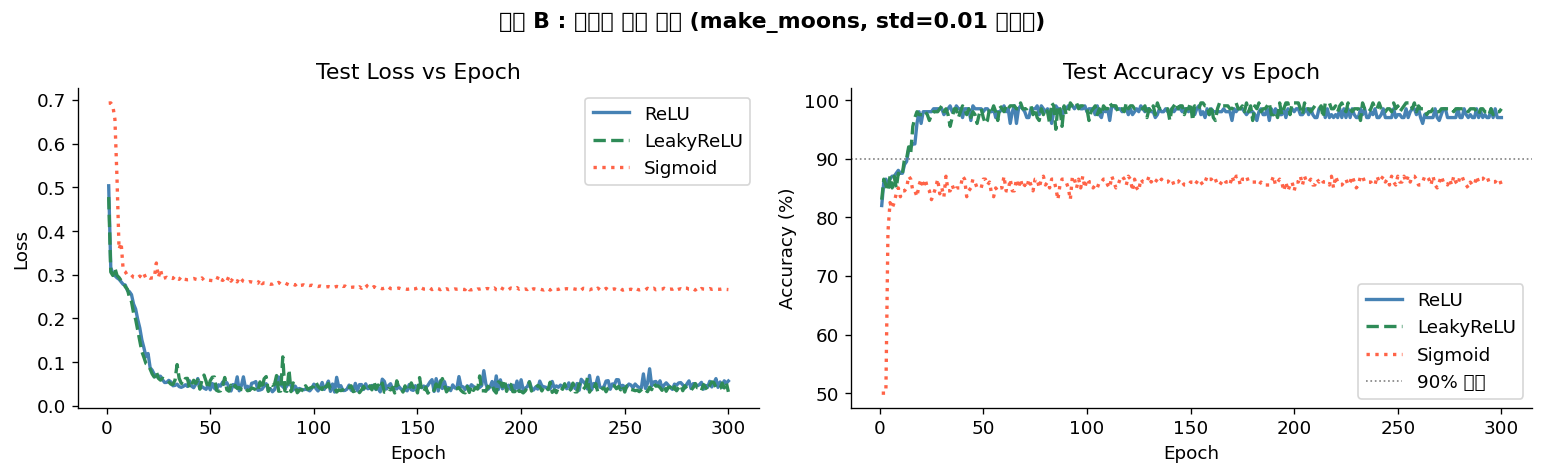

저장: exp_B_loss_acc.png


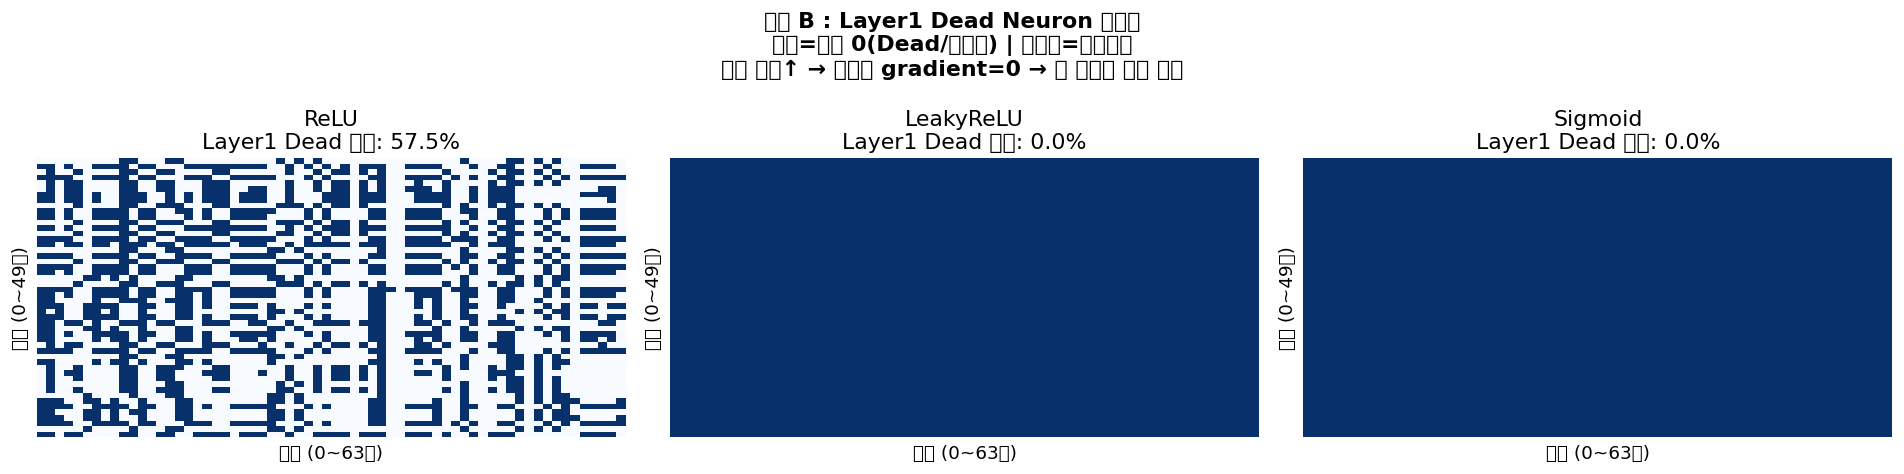

저장: exp_B_dead_heatmap.png


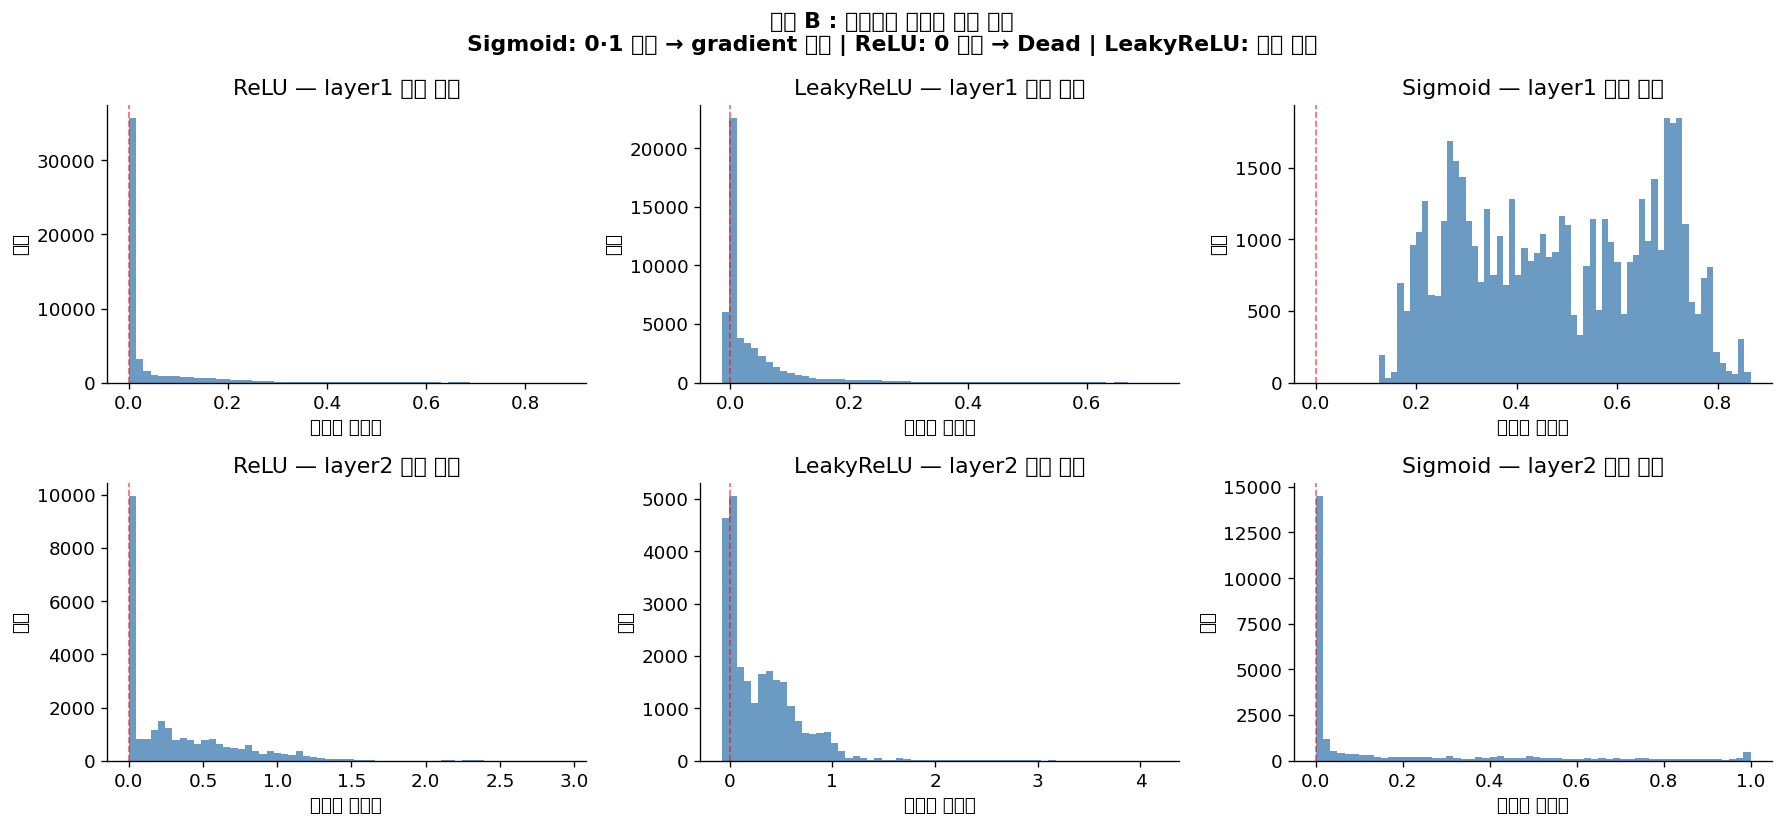

저장: exp_B_activation_dist.png


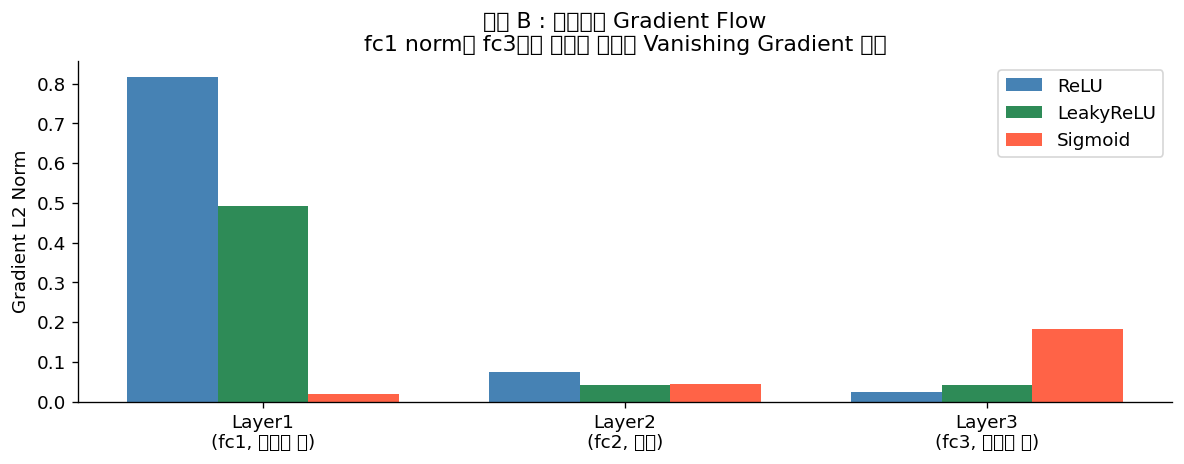

저장: exp_B_gradient_flow.png


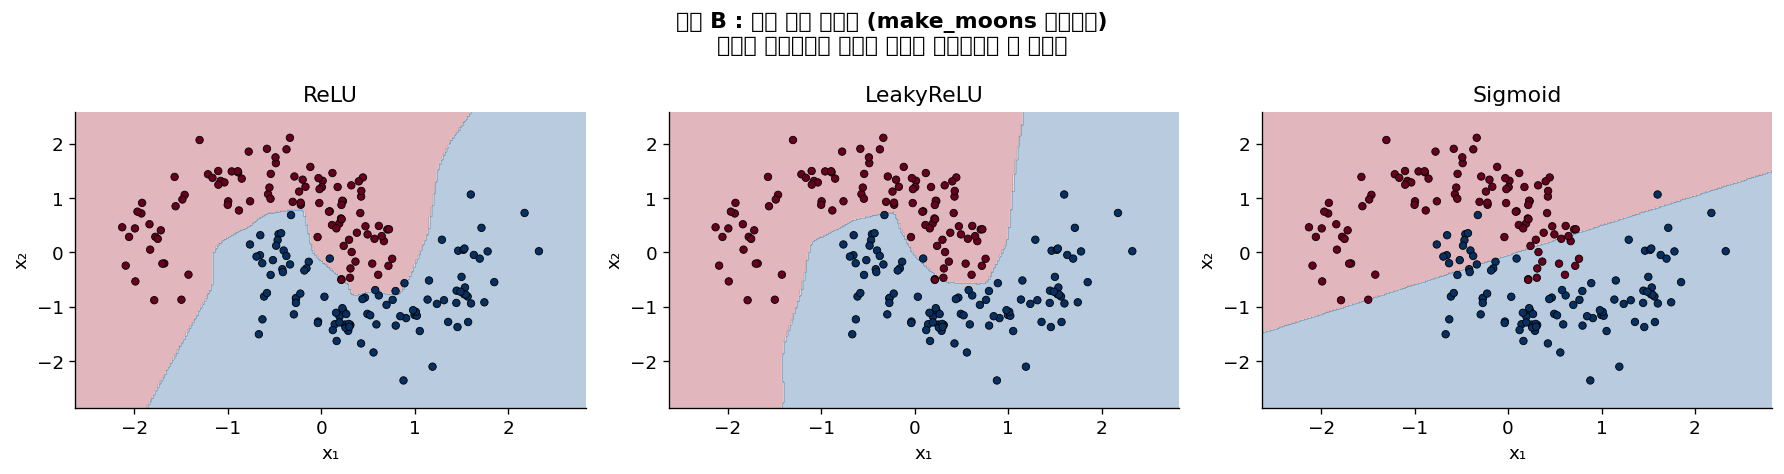

저장: exp_B_decision_boundary.png


In [9]:
ep_b = range(1, MOONS_EPOCH + 1)

# ── 그래프 1: Loss / Accuracy 곡선 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label, ls, color in [
    (hist_relu,    "ReLU",      "-",  "steelblue"),
    (hist_lrelu,   "LeakyReLU", "--", "seagreen"),
    (hist_sigmoid, "Sigmoid",   ":",  "tomato"),
]:
    axes[0].plot(ep_b, hist["test_loss"],
                 label=label, linestyle=ls, linewidth=2, color=color)
    axes[1].plot(ep_b, [a*100 for a in hist["test_acc"]],
                 label=label, linestyle=ls, linewidth=2, color=color)

axes[0].set_title("Test Loss vs Epoch"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Test Accuracy vs Epoch"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].axhline(90, color="gray", linestyle=":", linewidth=1, label="90% 기준")
axes[1].legend()
plt.suptitle("실험 B : 활성화 함수 비교 (make_moons, std=0.01 초기화)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("exp_B_loss_acc.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_B_loss_acc.png")

# ── 그래프 2: Dead Neuron 히트맵 ──────────────────────────────────────────────
# "Dead ReLU가 발생한 neuron 비율 측정 → 히트맵 시각화"
# 흰색=출력 0(Dead), 파란색=활성화됨
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n_show, n_neuron = 50, 64
for ax, (dead_res, title) in zip(axes, [
    (dead_relu,    "ReLU"),
    (dead_lrelu,   "LeakyReLU"),
    (dead_sigmoid, "Sigmoid"),
]):
    mat, ratio = dead_res["layer1"]
    sns.heatmap((mat[:n_show, :n_neuron] == 0).astype(float),
                ax=ax, cmap="Blues_r", cbar=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\nLayer1 Dead 비율: {ratio*100:.1f}%")
    ax.set_xlabel(f"뉴런 (0~{n_neuron-1}번)")
    ax.set_ylabel(f"샘플 (0~{n_show-1}번)")

plt.suptitle("실험 B : Layer1 Dead Neuron 히트맵\n"
             "흰색=출력 0(Dead/비활성) | 파란색=활성화됨\n"
             "흰색 비율↑ → 역전파 gradient=0 → 앞 레이어 학습 불가",
             fontweight="bold")
plt.tight_layout()
plt.savefig("exp_B_dead_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_B_dead_heatmap.png")

# ── 그래프 3: 레이어별 활성화 출력 분포 ──────────────────────────────────────
# "Layer별 출력값 시각화 (matplotlib 사용)"
# Sigmoid: 0~1 포화 구간 집중 → gradient≈0
# ReLU   : 0 집중 → Dead / LeakyReLU: 가장 분산
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, (dead_res, title) in enumerate([
    (dead_relu,    "ReLU"),
    (dead_lrelu,   "LeakyReLU"),
    (dead_sigmoid, "Sigmoid"),
]):
    for row, lkey in enumerate(["layer1", "layer2"]):
        mat, _ = dead_res[lkey]
        vals   = mat.flatten()
        axes[row][col].hist(vals, bins=60, color="steelblue", alpha=0.8)
        axes[row][col].set_title(f"{title} — {lkey} 출력 분포")
        axes[row][col].set_xlabel("활성화 출력값")
        axes[row][col].set_ylabel("빈도")
        axes[row][col].axvline(0, color="red", linestyle="--",
                               linewidth=1, alpha=0.6)
plt.suptitle("실험 B : 레이어별 활성화 출력 분포\n"
             "Sigmoid: 0·1 포화 → gradient 소멸 | "
             "ReLU: 0 집중 → Dead | LeakyReLU: 가장 균형",
             fontweight="bold")
plt.tight_layout()
plt.savefig("exp_B_activation_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_B_activation_dist.png")

# ── 그래프 4: 레이어별 Gradient Flow (L2 Norm) ───────────────────────────────
# "Gradient 흐름 시각화 → 어느 Layer에서 소멸하는지 분석"
# fc1(입력층 쪽) norm << fc3(출력층 쪽) norm → Vanishing Gradient 발생
def get_grad_norms_b(model):
    model.train()
    model.zero_grad()
    out  = model(X_tr[:64])
    nn.CrossEntropyLoss()(out, y_tr[:64]).backward()
    norms = {name: p.grad.norm().item()
             for name, p in model.named_parameters() if p.grad is not None}
    model.zero_grad()
    return norms

norms_relu    = get_grad_norms_b(model_relu)
norms_lrelu   = get_grad_norms_b(model_lrelu)
norms_sigmoid = get_grad_norms_b(model_sigmoid)

layer_keys   = ["fc1.weight", "fc2.weight", "fc3.weight"]
layer_labels = ["Layer1\n(fc1, 입력층 쪽)", "Layer2\n(fc2, 중간)",
                "Layer3\n(fc3, 출력층 쪽)"]
x_pos = np.arange(len(layer_keys)); width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - width, [norms_relu.get(k, 0)    for k in layer_keys],
       width, label="ReLU",      color="steelblue")
ax.bar(x_pos,         [norms_lrelu.get(k, 0)   for k in layer_keys],
       width, label="LeakyReLU", color="seagreen")
ax.bar(x_pos + width, [norms_sigmoid.get(k, 0) for k in layer_keys],
       width, label="Sigmoid",   color="tomato")
ax.set_xticks(x_pos); ax.set_xticklabels(layer_labels)
ax.set_ylabel("Gradient L2 Norm")
ax.set_title("실험 B : 레이어별 Gradient Flow\n"
             "fc1 norm이 fc3보다 현저히 작으면 Vanishing Gradient 발생")
ax.legend(); plt.tight_layout()
plt.savefig("exp_B_gradient_flow.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_B_gradient_flow.png")

# ── 그래프 5: 결정 경계 ────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    model.eval()
    with torch.no_grad():
        Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k",
               s=20, linewidths=0.5)
    ax.set_title(title); ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (mdl, title) in zip(axes, [
    (model_relu,    "ReLU"),
    (model_lrelu,   "LeakyReLU"),
    (model_sigmoid, "Sigmoid"),
]):
    plot_decision_boundary(mdl, X_test_b, y_test_b, title, ax)
plt.suptitle("실험 B : 결정 경계 시각화 (make_moons 테스트셋)\n"
             "경계가 정교할수록 활성화 함수가 비선형성을 잘 학습함",
             fontweight="bold")
plt.tight_layout()
plt.savefig("exp_B_decision_boundary.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_B_decision_boundary.png")


# ==============================================================================


## 실험 C : 최적화 알고리즘 비교 — SGD / SGD+Momentum / Adam


SGD          : θ_{t+1} = θ_t - η·∇L(θ_t)
               현재 gradient만 사용 → zig-zag 진동, Local Minimum 갇힘
SGD+Momentum : v_{t+1} = γ·v_t + η·∇L(θ_t),  θ_{t+1} = θ_t - v_{t+1}
               관성 효과(γ=0.9) → 진동 감소, 가속, Local Minimum 탈출 가능
Adam         : m_t = β1·m_{t-1} + (1-β1)·∇L   (방향, 1차 모멘트)
               v_t = β2·v_{t-1} + (1-β2)·(∇L)² (크기, 2차 모멘트)
               θ_{t+1} = θ_t - η·m̂_t/(√v̂_t + ε)
               Bias Correction으로 초기 과소추정 보정 → 초기 수렴 빠름
ExponentialLR: lr_t = lr_0 · 0.9^t
                초반 큰 lr → 빠른 탐색, 후반 작은 lr → 안정 수렴

[실험 조건]

동일: MLP(784→256→128→10, ReLU), CrossEntropy, 30 에폭, ExponentialLR(γ=0.9)
변경: optimizer + lr(0.1/0.01/0.001) 조합


In [10]:
print("\n" + "=" * 60)
print("실험 C : Optimizer 비교 (SGD / SGD+Momentum / Adam)")
print("=" * 60)

LR_LIST = [0.1, 0.01, 0.001]   # 세 값으로 overshooting·정체 모두 관찰

# results_c[optimizer_name][lr] = history
results_c = {"SGD": {}, "SGD+Momentum": {}, "Adam": {}}

for lr in LR_LIST:
    print(f"\n── lr={lr} ──────────────────────────────────────────────")

    # ── SGD ──────────────────────────────────────────────────────────────────
    # 기본 경사하강법. 현재 gradient만 사용.
    # SGD: 0.01~0.1
    print(f"  [C-SGD] lr={lr}")
    m   = build_model(nn.ReLU())
    opt = optim.SGD(m.parameters(), lr=lr)
    sch = optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    results_c["SGD"][lr] = run_experiment(
        m, nn.CrossEntropyLoss(), opt, FMNIST_EPOCH,
        scheduler=sch, verbose_interval=10)

    # ── SGD + Momentum ────────────────────────────────────────────────────────
    # momentum=0.9: 이전 이동 방향의 90%를 현재 업데이트에 반영
    # 같은 방향 지속 → 속도 누적(가속) / 반대 방향 → 상쇄(진동 감소)
    # SGD+Momentum: 0.01~0.05
    print(f"  [C-SGD+Mom] lr={lr}")
    m   = build_model(nn.ReLU())
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    sch = optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    results_c["SGD+Momentum"][lr] = run_experiment(
        m, nn.CrossEntropyLoss(), opt, FMNIST_EPOCH,
        scheduler=sch, verbose_interval=10)

    # ── Adam ──────────────────────────────────────────────────────────────────
    # betas=(0.9, 0.999): β1=0.9, β2=0.999 표준값
    # eps=1e-8: 분모 0 방지 (수치 안정성)
    # Adam: 0.001~0.01
    print(f"  [C-Adam] lr={lr}")
    m   = build_model(nn.ReLU())
    opt = optim.Adam(m.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8)
    sch = optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    results_c["Adam"][lr] = run_experiment(
        m, nn.CrossEntropyLoss(), opt, FMNIST_EPOCH,
        scheduler=sch, verbose_interval=10)

# ── 실험 C 보고서 표 출력 ──────────────────────────────────────────────────────
print_table_C(results_c)


# ==============================================================================



실험 C : Optimizer 비교 (SGD / SGD+Momentum / Adam)

── lr=0.1 ──────────────────────────────────────────────
  [C-SGD] lr=0.1
  Epoch   1/30 | Train Loss: 0.5754  Acc: 78.98%  | Test Loss: 0.4646  Acc: 82.64%
  Epoch  10/30 | Train Loss: 0.2292  Acc: 91.56%  | Test Loss: 0.3294  Acc: 88.15%
  Epoch  20/30 | Train Loss: 0.1638  Acc: 94.03%  | Test Loss: 0.3021  Acc: 89.41%
  Epoch  30/30 | Train Loss: 0.1363  Acc: 95.34%  | Test Loss: 0.3087  Acc: 89.49%
  [C-SGD+Mom] lr=0.1
  Epoch   1/30 | Train Loss: 0.6546  Acc: 77.17%  | Test Loss: 0.5825  Acc: 80.73%
  Epoch  10/30 | Train Loss: 0.2850  Acc: 89.46%  | Test Loss: 0.3771  Acc: 87.15%
  Epoch  20/30 | Train Loss: 0.1928  Acc: 92.67%  | Test Loss: 0.3661  Acc: 88.39%
  Epoch  30/30 | Train Loss: 0.1496  Acc: 94.41%  | Test Loss: 0.3861  Acc: 88.58%
  [C-Adam] lr=0.1
  Epoch   1/30 | Train Loss: 4.9668  Acc: 12.69%  | Test Loss: 2.3151  Acc: 10.09%
  Epoch  10/30 | Train Loss: 2.0444  Acc: 19.20%  | Test Loss: 2.0033  Acc: 18.00%
  Epoch

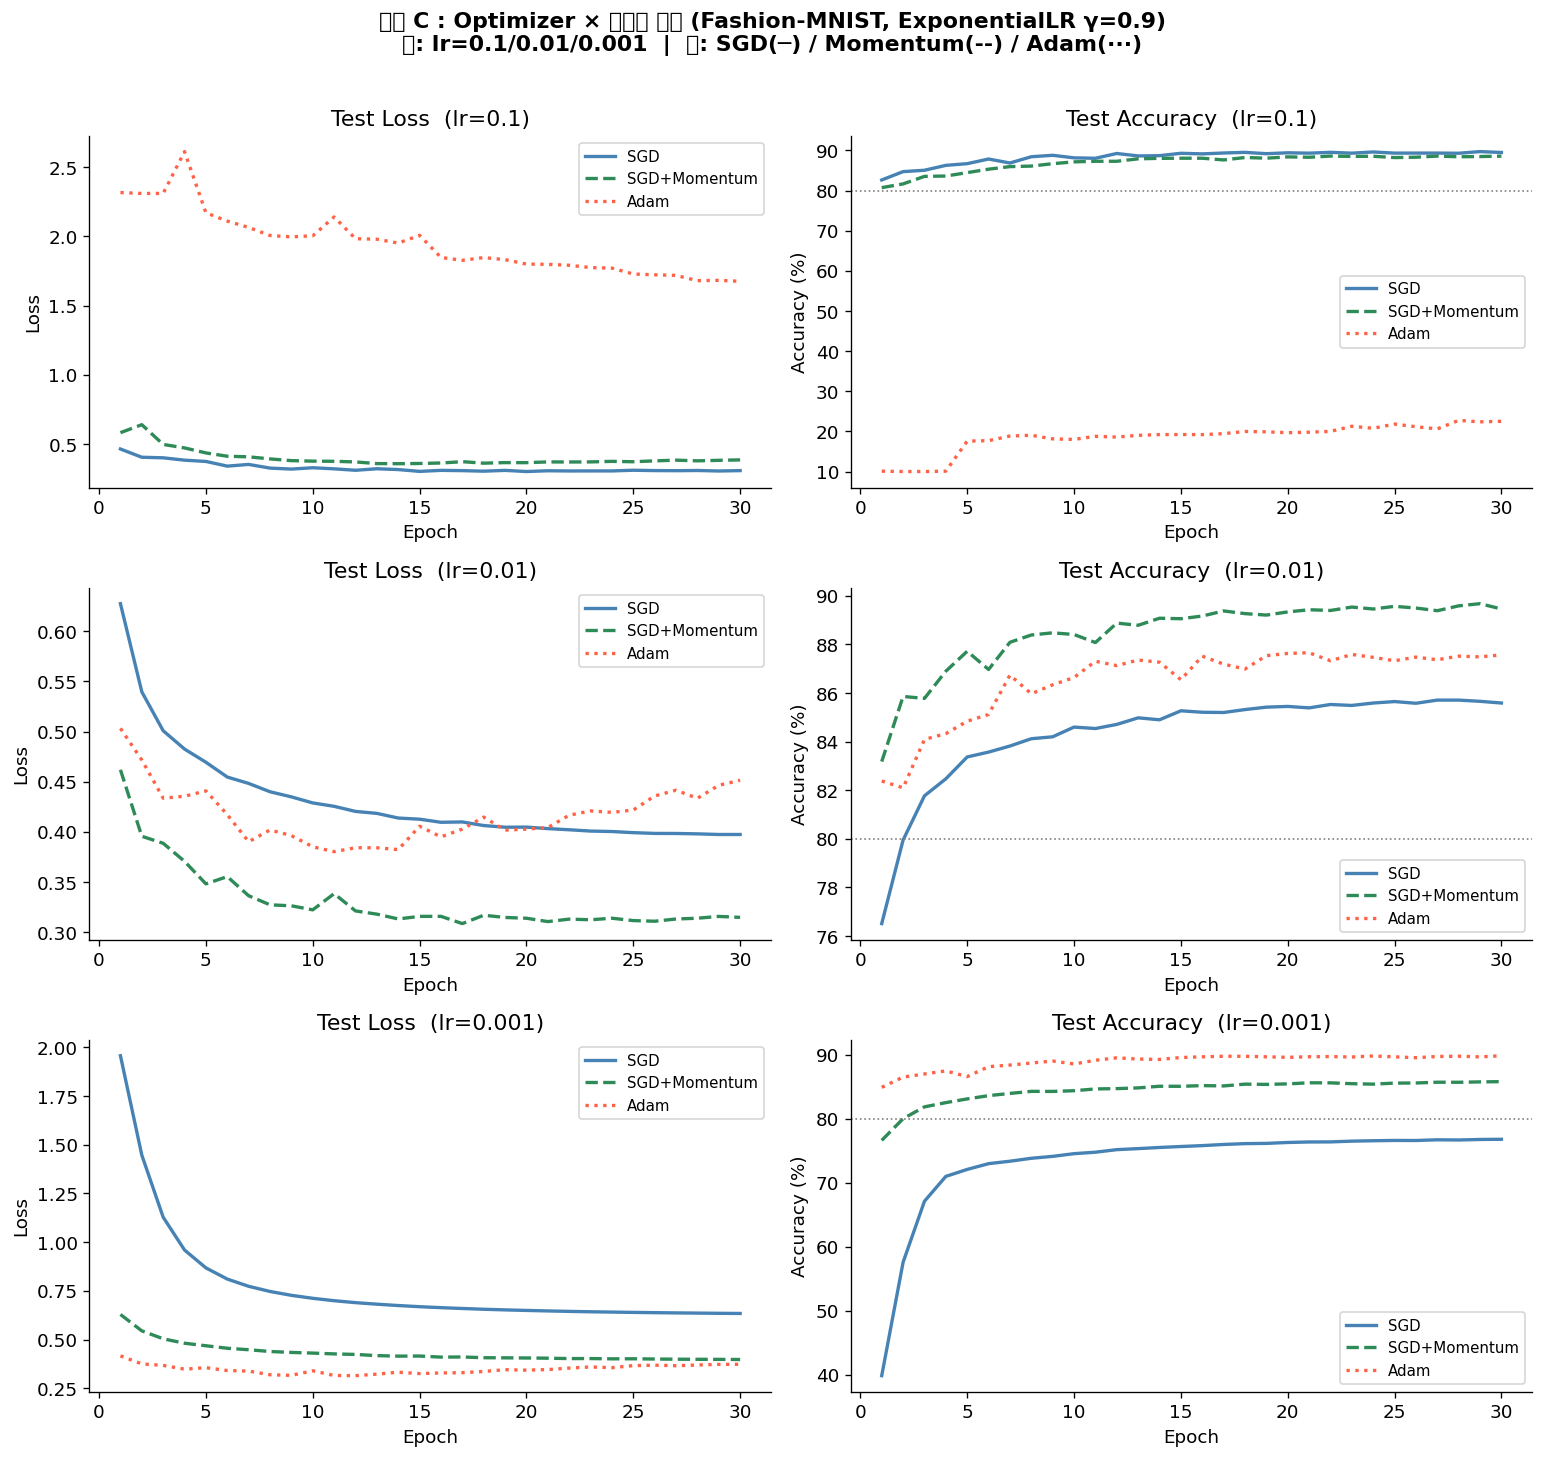

저장: exp_C_optimizer_curves.png

[참고] lr=0.01 기준 Gradient Norm 측정 중... (재학습 필요, 시간 소요)


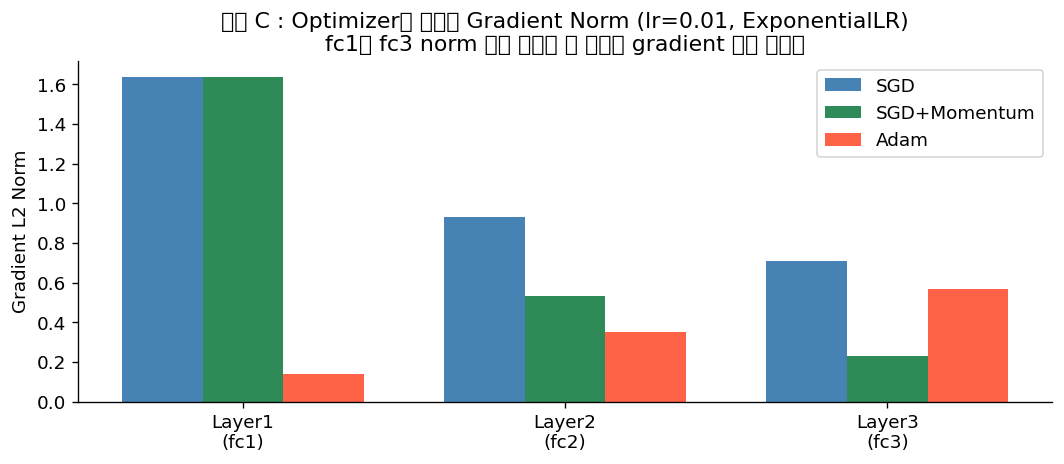

저장: exp_C_gradient_norm.png


In [11]:
ep_c = range(1, FMNIST_EPOCH + 1)
colors = {"SGD": "steelblue", "SGD+Momentum": "seagreen", "Adam": "tomato"}
styles = {"SGD": "-", "SGD+Momentum": "--", "Adam": ":"}

# ── 그래프 1: Loss / Accuracy 곡선 (3×2 그리드) ───────────────────────────────
# 행=lr(0.1/0.01/0.001), 열=Loss·Accuracy
# lr=0.1행: SGD overshooting / lr=0.001행: SGD 정체, Adam 적응형 효과 확인
fig, axes = plt.subplots(len(LR_LIST), 2, figsize=(13, 4 * len(LR_LIST)))
for row, lr in enumerate(LR_LIST):
    for opt_name in ["SGD", "SGD+Momentum", "Adam"]:
        hist = results_c[opt_name][lr]
        axes[row][0].plot(ep_c, hist["test_loss"],
                          label=opt_name, color=colors[opt_name],
                          linestyle=styles[opt_name], linewidth=2)
        axes[row][1].plot(ep_c, [a*100 for a in hist["test_acc"]],
                          label=opt_name, color=colors[opt_name],
                          linestyle=styles[opt_name], linewidth=2)
    axes[row][0].set_title(f"Test Loss  (lr={lr})")
    axes[row][0].set_xlabel("Epoch"); axes[row][0].set_ylabel("Loss")
    axes[row][0].legend(fontsize=9)
    axes[row][1].set_title(f"Test Accuracy  (lr={lr})")
    axes[row][1].set_xlabel("Epoch"); axes[row][1].set_ylabel("Accuracy (%)")
    axes[row][1].axhline(80, color="gray", linestyle=":", linewidth=1)
    axes[row][1].legend(fontsize=9)

plt.suptitle("실험 C : Optimizer × 학습률 비교 (Fashion-MNIST, ExponentialLR γ=0.9)\n"
             "행: lr=0.1/0.01/0.001  |  선: SGD(─) / Momentum(--) / Adam(···)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("exp_C_optimizer_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_C_optimizer_curves.png")

# ── 그래프 2: Gradient Norm (lr=0.01 기준 재학습) ────────────────────────────
# fc1(입력층 쪽) norm << fc3(출력층 쪽) norm → Vanishing Gradient
# Adam: 2차 모멘트가 gradient 크기 정규화 → 레이어 간 norm 균형
# SGD+Momentum: velocity 누적으로 방향 안정화
# SGD: 레이어 간 편차 상대적으로 큼

ref_lr = 0.01
print(f"\n[참고] lr={ref_lr} 기준 Gradient Norm 측정 중... (재학습 필요, 시간 소요)")

def train_and_get_grad_norms(opt_name, lr):
    """
    새 모델을 FMNIST_EPOCH 에폭 학습 후
    마지막 배치의 레이어별 gradient L2 Norm 반환.

    L2 Norm = sqrt(Σ grad²): gradient 전체 크기 대표값.
    값이 클수록 해당 레이어가 학습에 활발히 기여.
    """
    m = build_model(nn.ReLU())
    if opt_name == "SGD":
        opt = optim.SGD(m.parameters(), lr=lr)
    elif opt_name == "SGD+Momentum":
        opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    else:
        opt = optim.Adam(m.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8)

    loss_fn_c = nn.CrossEntropyLoss()
    sch = optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)

    for _ in range(FMNIST_EPOCH):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn_c(m(xb), yb).backward()
            opt.step()
        sch.step()

    # 마지막 배치 gradient 수집
    xb, yb = next(iter(train_loader))
    xb, yb = xb.to(device), yb.to(device)
    m.zero_grad()
    loss_fn_c(m(xb), yb).backward()
    norms = {name: p.grad.norm().item()
             for name, p in m.named_parameters() if p.grad is not None}
    return norms

gn_sgd  = train_and_get_grad_norms("SGD",          ref_lr)
gn_mom  = train_and_get_grad_norms("SGD+Momentum", ref_lr)
gn_adam = train_and_get_grad_norms("Adam",         ref_lr)

layer_keys_c   = ["fc1.weight", "fc2.weight", "fc3.weight"]
layer_labels_c = ["Layer1\n(fc1)", "Layer2\n(fc2)", "Layer3\n(fc3)"]
x_g = np.arange(len(layer_keys_c)); w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_g - w, [gn_sgd.get(k, 0)  for k in layer_keys_c],
       w, label="SGD",          color="steelblue")
ax.bar(x_g,     [gn_mom.get(k, 0)  for k in layer_keys_c],
       w, label="SGD+Momentum", color="seagreen")
ax.bar(x_g + w, [gn_adam.get(k, 0) for k in layer_keys_c],
       w, label="Adam",         color="tomato")
ax.set_xticks(x_g); ax.set_xticklabels(layer_labels_c)
ax.set_ylabel("Gradient L2 Norm")
ax.set_title(f"실험 C : Optimizer별 레이어 Gradient Norm (lr={ref_lr}, ExponentialLR)\n"
             "fc1과 fc3 norm 차이 클수록 앞 레이어 gradient 전달 어려움")
ax.legend(); plt.tight_layout()
plt.savefig("exp_C_gradient_norm.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: exp_C_gradient_norm.png")


# ==============================================================================


## 전체 실험 완료 — 최종 요약 출력

아래 출력 - 보고서 표


In [12]:
print("\n\n" + "█" * 70)
print("  전체 실험 완료 — 최종 요약 (보고서 표 작성용)")
print("█" * 70)

print("\n저장된 그래프 파일 목록:")
files = [
    ("exp_A_loss_acc.png",          "실험 A | Loss/Accuracy 곡선"),
    ("exp_A_gradient.png",          "실험 A | fc1 Gradient 분포"),
    ("exp_B_loss_acc.png",          "실험 B | Loss/Accuracy 곡선"),
    ("exp_B_dead_heatmap.png",      "실험 B | Dead Neuron 히트맵"),
    ("exp_B_activation_dist.png",   "실험 B | 레이어별 활성화 분포"),
    ("exp_B_gradient_flow.png",     "실험 B | Gradient Flow"),
    ("exp_B_decision_boundary.png", "실험 B | 결정 경계"),
    ("exp_C_optimizer_curves.png",  "실험 C | Optimizer × lr 곡선"),
    ("exp_C_gradient_norm.png",     "실험 C | Gradient Norm 비교"),
]
for fname, desc in files:
    print(f"  {fname:<36} ← {desc}")



██████████████████████████████████████████████████████████████████████
  전체 실험 완료 — 최종 요약 (보고서 표 작성용)
██████████████████████████████████████████████████████████████████████

저장된 그래프 파일 목록:
  exp_A_loss_acc.png                   ← 실험 A | Loss/Accuracy 곡선
  exp_A_gradient.png                   ← 실험 A | fc1 Gradient 분포
  exp_B_loss_acc.png                   ← 실험 B | Loss/Accuracy 곡선
  exp_B_dead_heatmap.png               ← 실험 B | Dead Neuron 히트맵
  exp_B_activation_dist.png            ← 실험 B | 레이어별 활성화 분포
  exp_B_gradient_flow.png              ← 실험 B | Gradient Flow
  exp_B_decision_boundary.png          ← 실험 B | 결정 경계
  exp_C_optimizer_curves.png           ← 실험 C | Optimizer × lr 곡선
  exp_C_gradient_norm.png              ← 실험 C | Gradient Norm 비교
